In [1]:
! pip install pandas numpy matplotlib scikit-learn yfinance

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed


MSE: 4.55
R2 Score: 0.99


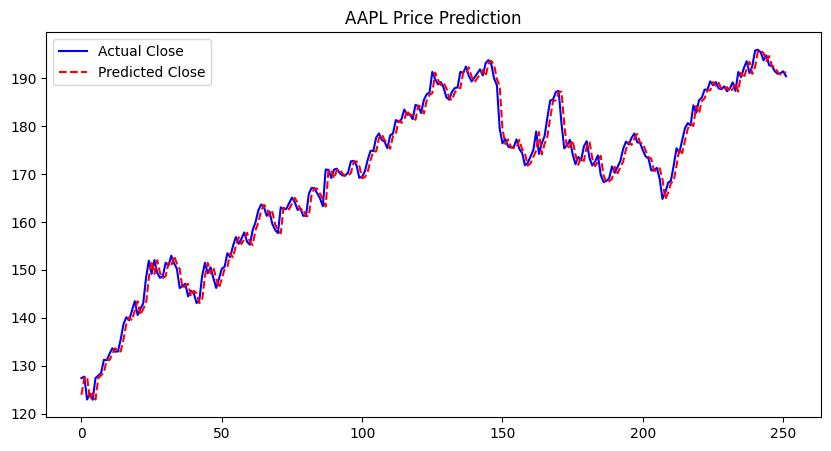

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fetch AAPL data for the last 5 years
ticker = "AAPL"
df = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# We only really need the closing prices for this simple model
data = df[['Close']].copy()

# Set up the target variable (predicting tomorrow's closing price)
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True) # Drop the last row since it has no 'next day'

X = data[['Close']].values
y = data['Target'].values

# Split data (keeping shuffle=False since it's time series data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Test predictions
preds = lr_model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, preds):.2f}")
print(f"R2 Score: {r2_score(y_test, preds):.2f}")

# Quick plot to check how we did
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Close', color='blue')
plt.plot(preds, label='Predicted Close', color='red', linestyle='--')
plt.title(f'{ticker} Price Prediction')
plt.legend()
plt.show()